# Detecção de objetos usando mapas de ativação — Experimentos

Este notebook segue o roteiro proposto para detecção de objetos utilizando mapas de ativação de redes neurais convolucionais. O objetivo é identificar a posição de um cachorro em imagens onde ele ocupa uma pequena parte da cena, utilizando diferentes variantes da ResNet.

In [10]:
import sys
import os
from PIL import Image
from src.visualization import ObjectDetectionVisualizer

sys.path.insert(0, os.path.abspath('src'))


## 1. Coleta das imagens

Faça o download de 10 imagens da internet contendo cachorros que ocupam uma pequena parte da imagem. Salve-as em uma pasta, por exemplo, `imagens_cachorros/`.

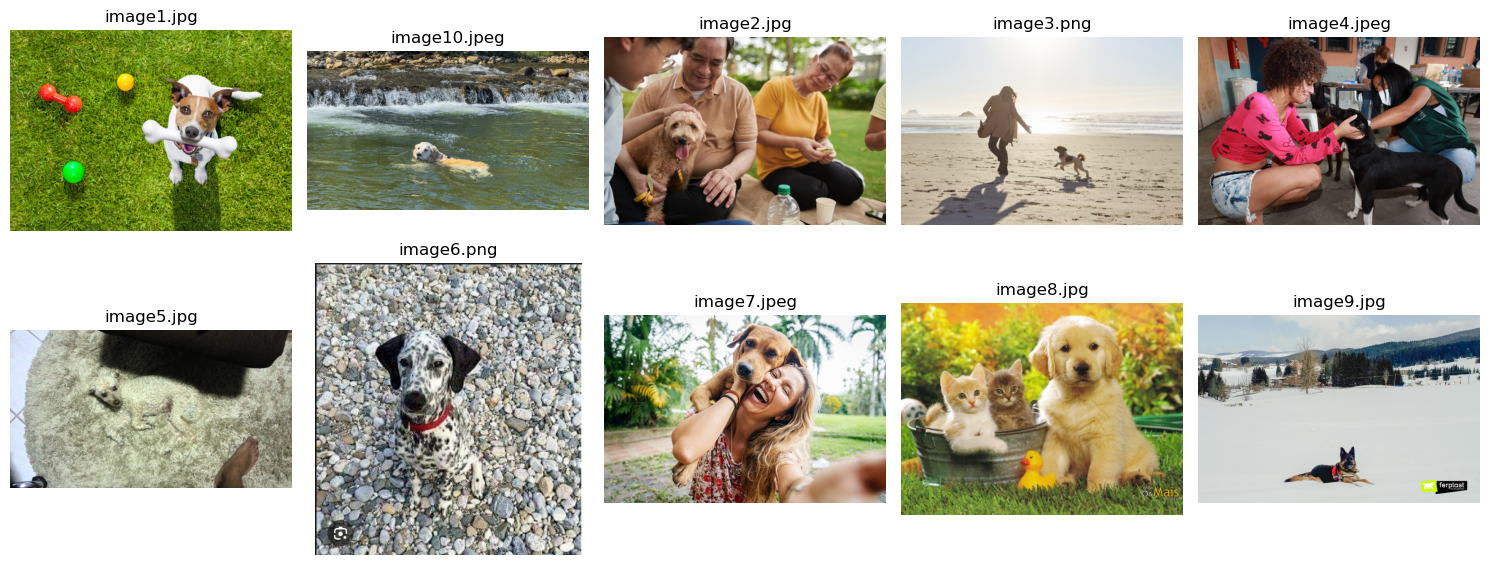

In [11]:

# Caminho para as imagens
dog_images_path = 'images_dogs/'
dog_image_names = [f for f in os.listdir(dog_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Visualizar as imagens em grid
ObjectDetectionVisualizer.show_images_grid(dog_images_path, dog_image_names, n_rows=2, n_cols=5)

## 2. Obtenção das ativações da última camada da ResNet18 treinada no ImageNet

Utilizaremos a ResNet18 pré-treinada no ImageNet para extrair o mapa de ativações antes do global pooling.

In [12]:
from src.object_detection import ImageTransforms, ActivationMapResNet18

# Inicializar transformações e modelo
transforms = ImageTransforms()
model_resnet18 = ActivationMapResNet18()

## 3. Detecção da posição do valor máximo da ativação

Para cada imagem, vamos identificar a posição do valor máximo no mapa de ativação.

In [13]:
from src.object_detection import detect_max_activation

def detectar_maximo_ativacao(mapa_ativacao):
    return detect_max_activation(mapa_ativacao)

## 4. Cálculo da posição respectiva na imagem original

Como a imagem é redimensionada para 448x448 e o mapa de ativação é 14x14, é necessário calcular a posição correspondente na imagem original.

In [22]:
from src.object_detection import map_activation_to_original


def posicao_na_imagem_original(pos_ativacao, tamanho_original, tamanho_redimensionado=(448,448), tamanho_mapa=(14,14)):
    return map_activation_to_original(pos_ativacao, tamanho_original, tamanho_redimensionado, tamanho_mapa)

## 5. Repetição com outros modelos

Repita o procedimento para a ResNet18 refinada no Oxford Pets e para a ResNet50 treinada no ImageNet. Basta adaptar a classe do modelo conforme necessário.

In [23]:
from src.object_detection import ActivationMapResNet50

model_resnet50 = ActivationMapResNet50()
# Para a ResNet18 refinada, carregue os pesos customizados se disponíveis

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/wesleygalvao/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 32.8MB/s]
100%|██████████| 97.8M/97.8M [00:03<00:00, 32.8MB/s]


## 6. Avaliação qualitativa

Visualize os resultados marcando a posição detectada sobre a imagem original e discuta a acurácia qualitativamente.

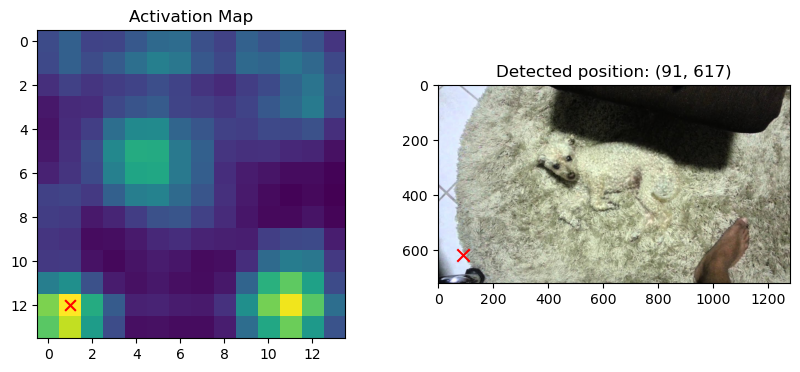

In [14]:
from src.visualization import ObjectDetectionVisualizer

# Exemplo de visualização para uma imagem
def visualizar_resultado(img_id=0, model=None, transform=None):
    if model is None:
        from src.object_detection import ActivationMapResNet18
        model = ActivationMapResNet18()
    if transform is None:
        from src.object_detection import ImageTransforms
        transform = ImageTransforms()
    ObjectDetectionVisualizer.plot_activation_and_detection(
        img_path=None,  # não é mais necessário, pois usamos o diretório e lista de nomes
        model=model,
        transform=transform,
        image_names=dog_image_names,
        image_dir=dog_images_path,
        img_id=img_id
    )

# Exemplo de uso:
visualizar_resultado(img_id=5, model=model_resnet18, transform=transforms)

---

Preencha as células com os resultados e discussões qualitativas após rodar os experimentos.